In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv to Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Saving Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv to Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv


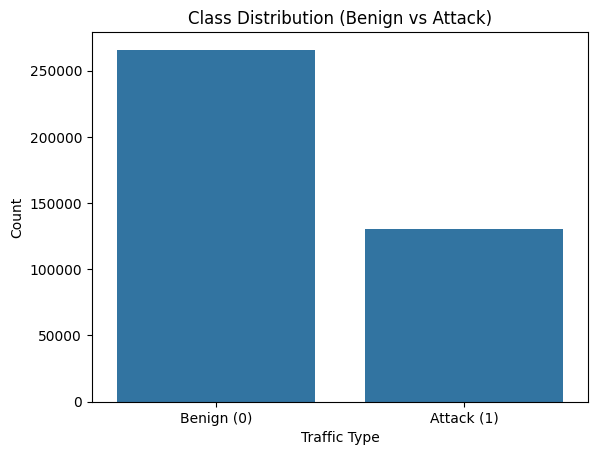

Class counts:
 AttackLabel
0    265737
1    130205
Name: count, dtype: int64
Logistic Regression Training Accuracy: 0.985916471193643
Logistic Regression Testing Accuracy: 0.9857934814178737


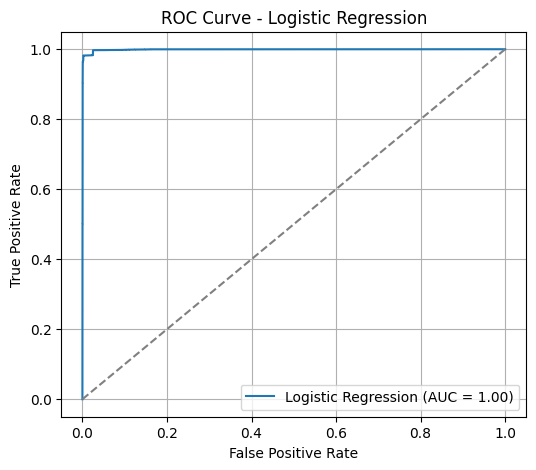


Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99     53042
           1       0.97      0.98      0.98     26147

    accuracy                           0.99     79189
   macro avg       0.98      0.98      0.98     79189
weighted avg       0.99      0.99      0.99     79189



In [ ]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_curve, auc

# 1. Loading both CICIDS CSVs
df1 = pd.read_csv('Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv', low_memory=False)
df2 = pd.read_csv('Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv', low_memory=False)

# 2. Combing and strip extra spaces in column names
df = pd.concat([df1, df2], ignore_index=True)
df.columns = df.columns.str.strip()

# 3. Cleaning data: replace infinities, drop NaNs
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# 4. Creating binary label: 0 = BENIGN, 1 = ATTACK
df['AttackLabel'] = df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

# 5. Prepareing features (X) and target (y)
X = df.drop(['Label', 'AttackLabel'], axis=1)
y = df['AttackLabel']
sns.countplot(x=y)
plt.title('Class Distribution (Benign vs Attack)')
plt.xticks([0, 1], ['Benign (0)', 'Attack (1)'])
plt.xlabel('Traffic Type')
plt.ylabel('Count')
plt.show()

print("Class counts:\n", y.value_counts())


# 6. Split into train & test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 7. Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 8. Train baseline model
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

train_preds_lr = lr.predict(X_train_scaled)
print("Logistic Regression Training Accuracy:", accuracy_score(y_train, train_preds_lr))


# 9. Evaluate
y_pred = lr.predict(X_test_scaled)
print("Logistic Regression Testing Accuracy:", accuracy_score(y_test, y_pred))

lr_probs = lr.predict_proba(X_test_scaled)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
roc_auc_lr = auc(fpr_lr, tpr_lr)

plt.figure(figsize=(6,5))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.title('ROC Curve - Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()
print("\nClassification Report:\n", classification_report(y_test, y_pred))


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# 1. Defining the RF and parameter grid
rf = RandomForestClassifier(random_state=42)
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 20],
}

# 2. Set up GridSearchCV (using 3‑fold CV and AUC as scoring)
grid = GridSearchCV(
    rf,
    param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

#  3. Fit on the training data BEFORE accessing best_rf
grid.fit(X_train_scaled, y_train)

#  4. getting best model
best_rf = grid.best_estimator_

# 5. Predict on both training and test data
train_preds_rf = best_rf.predict(X_train_scaled)
y_rf_pred = best_rf.predict(X_test_scaled)
#  RF predictions and scores for visualizations
y_rf     = best_rf.predict(X_test)
score_rf = best_rf.predict_proba(X_test)[:, 1]

#  6. Print results
print("Best Random Forest parameters:", grid.best_params_)
print("Random Forest Test Accuracy:", accuracy_score(y_test, y_rf_pred))
print("Random Forest Training Accuracy:", accuracy_score(y_train, train_preds_rf))
print("Random Forest Classification Report:\n", classification_report(y_test, y_rf_pred))


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Best Random Forest parameters: {'max_depth': None, 'n_estimators': 100}
Random Forest Test Accuracy: 0.9996969276035813
Random Forest Training Accuracy: 1.0
Random Forest Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     53042
           1       1.00      1.00      1.00     26147

    accuracy                           1.00     79189
   macro avg       1.00      1.00      1.00     79189
weighted avg       1.00      1.00      1.00     79189



In [ ]:
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report

print("\n=== XGBoost & LightGBM (defaults) ===")

# XGBoost
xgbc = xgb.XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgbc.fit(X_train, y_train)
train_preds_xgb = xgbc.predict(X_train)
print("XGBoost Training Accuracy:", accuracy_score(y_train, train_preds_xgb))
y_xgb = xgbc.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, y_xgb))
print(classification_report(y_test, y_xgb))

# LightGBM
lgbm = lgb.LGBMClassifier(random_state=42)
lgbm.fit(X_train, y_train)
train_preds_lgb = lgbm.predict(X_train)
print("LightGBM Training Accuracy:", accuracy_score(y_train, train_preds_lgb))
y_lgb = lgbm.predict(X_test)
print("LightGBM Accuracy:", accuracy_score(y_test, y_lgb))
print(classification_report(y_test, y_lgb))

# Logistic Regression (needs scaled features)
y_lr     = lr.predict(X_test_scaled)
score_lr = lr.predict_proba(X_test_scaled)[:, 1]

# Random Forest
y_rf     = best_rf.predict(X_test)
score_rf = best_rf.predict_proba(X_test)[:, 1]

# XGBoost
y_xgb     = xgbc.predict(X_test)
score_xgb = xgbc.predict_proba(X_test)[:, 1]

# LightGBM
y_lgb     = lgbm.predict(X_test)
score_lgb = lgbm.predict_proba(X_test)[:, 1]

print("✅ Saved all model predictions and scores.")



=== XGBoost & LightGBM (defaults) ===


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:07:27] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost Training Accuracy: 0.9999936859319407
XGBoost Accuracy: 0.9998737198348255
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     53042
           1       1.00      1.00      1.00     26147

    accuracy                           1.00     79189
   macro avg       1.00      1.00      1.00     79189
weighted avg       1.00      1.00      1.00     79189

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 104058, number of negative: 212695
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.104614 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14521
[LightGBM] [Info] Number of data points in the train set: 316753, number of used features: 68
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.328515 -> initscore=-0.714911
[L

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


✅ Saved all model predictions and scores.


In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, classification_report

print("\n Isolation Forest (unsupervised)")

# Train only on benign flows (use X_train_scaled)
iso = IsolationForest(
    n_estimators=100,
    contamination=0.01,
    random_state=42
)
iso.fit(X_train_scaled[y_train == 0])

# Predict on the full test set (use X_test_scaled)
y_iso = (iso.predict(X_test_scaled) == -1).astype(int)

# Evaluate
print("Isolation Forest Accuracy:", accuracy_score(y_test, y_iso))
print("\nClassification Report:\n", classification_report(y_test, y_iso))

# Naive response stub: save flagged anomalies
df_flags = X_test.copy()
df_flags['TrueLabel']   = y_test.values
df_flags['AnomalyFlag'] = y_iso
df_flags[df_flags['AnomalyFlag']==1] \
    .to_csv('flagged_anomalies.csv', index=False)
print("Saved", df_flags['AnomalyFlag'].sum(), "anomalies to flagged_anomalies.csv")




 Isolation Forest (unsupervised)
Isolation Forest Accuracy: 0.6814330273143997

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.99      0.81     53042
           1       0.72      0.06      0.11     26147

    accuracy                           0.68     79189
   macro avg       0.70      0.52      0.46     79189
weighted avg       0.69      0.68      0.58     79189

Saved 2116 anomalies to flagged_anomalies.csv


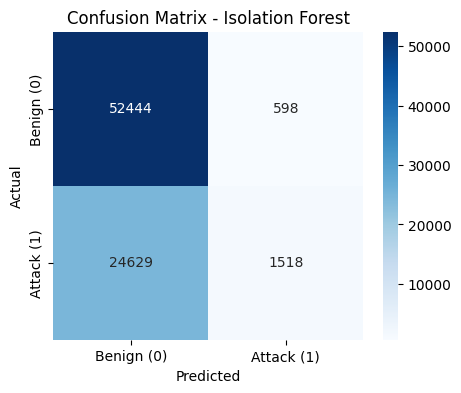

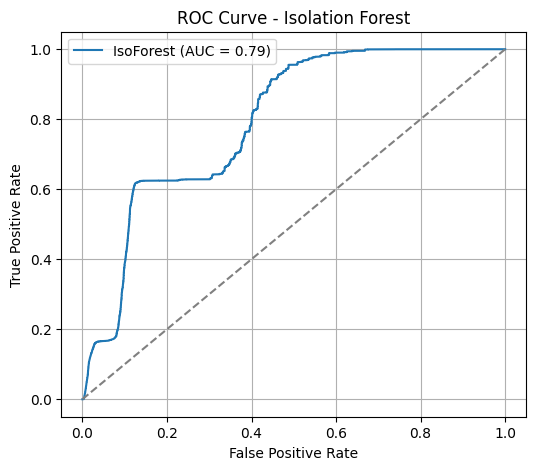

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

# Compute scores
scores = iso.decision_function(X_test_scaled)

# 1️ Confusion Matrix + Heatmap
cm = confusion_matrix(y_test, y_iso)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign (0)','Attack (1)'],
            yticklabels=['Benign (0)','Attack (1)'])
plt.title('Confusion Matrix - Isolation Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 2️ ROC Curve
# Invert scores so higher = anomaly
fpr, tpr, _ = roc_curve(y_test, -scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'IsoForest (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.title('ROC Curve - Isolation Forest')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()


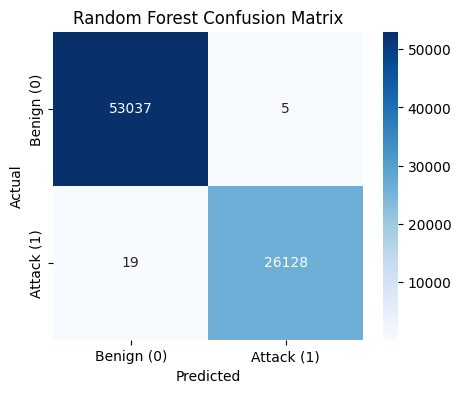

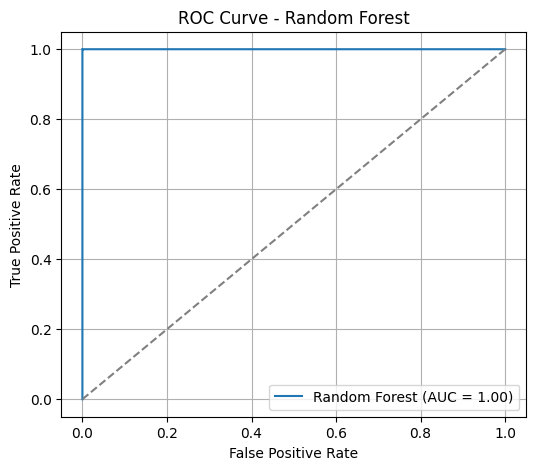

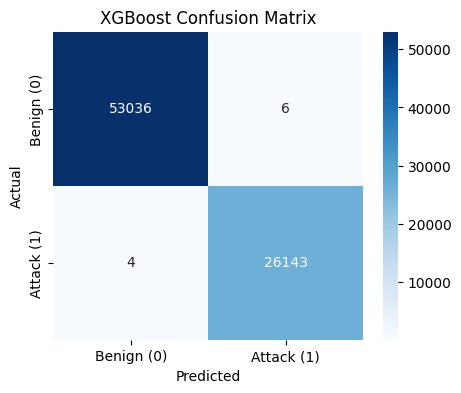

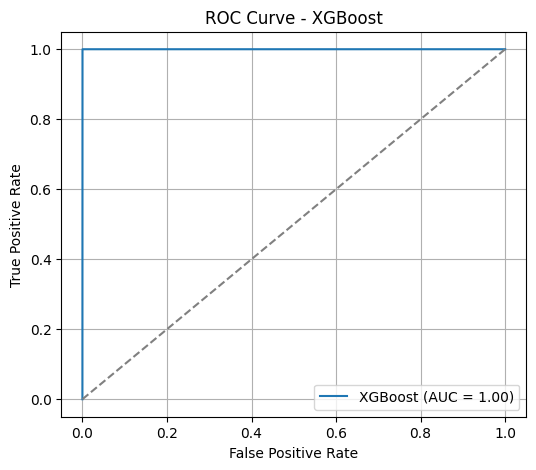

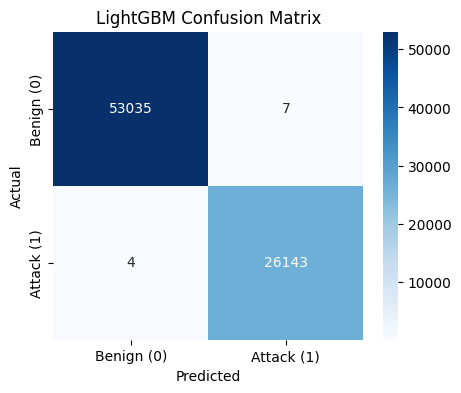

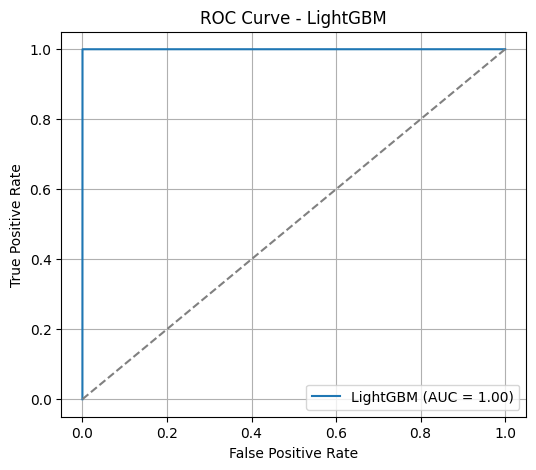

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

# Gathering predictions and scores for each model
results = {
    'Random Forest': {
        'preds': best_rf.predict(X_test_scaled),
        'scores': best_rf.predict_proba(X_test_scaled)[:,1]
    },
    'XGBoost': {
        'preds': xgbc.predict(X_test),
        'scores': xgbc.predict_proba(X_test)[:,1]
    },
    'LightGBM': {
        'preds': lgbm.predict(X_test),
        'scores': lgbm.predict_proba(X_test)[:,1]
    }
}

for name, res in results.items():
    y_pred = res['preds']
    y_score = res['scores']

    # 1️ Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Benign (0)','Attack (1)'],
                yticklabels=['Benign (0)','Attack (1)'])
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # 2️ ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')
    plt.plot([0,1],[0,1], linestyle='--', color='gray')
    plt.title(f'ROC Curve - {name}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.grid(True)
    plt.show()


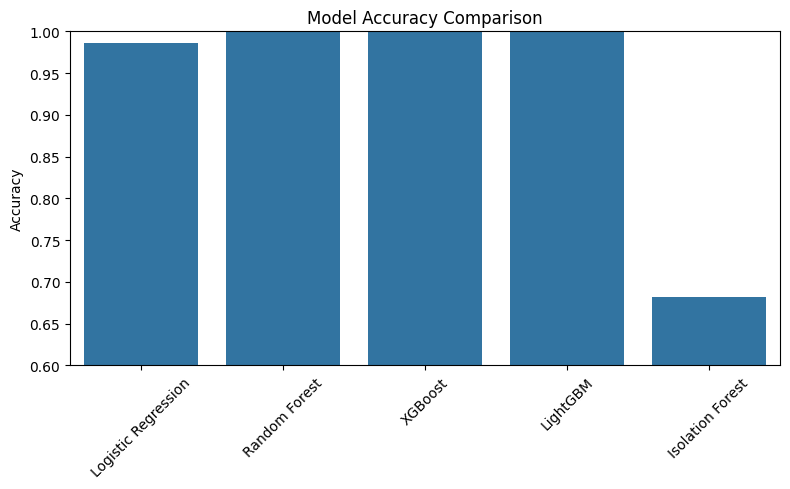

In [ ]:
accuracies = {
    'Logistic Regression': accuracy_score(y_test, lr.predict(X_test_scaled)),
    'Random Forest': accuracy_score(y_test, best_rf.predict(X_test_scaled)),
    'XGBoost': accuracy_score(y_test, xgbc.predict(X_test)),
    'LightGBM': accuracy_score(y_test, lgbm.predict(X_test)),
    'Isolation Forest': accuracy_score(y_test, y_iso)
}

plt.figure(figsize=(8,5))
sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()))
plt.ylim(0.6, 1.0)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
print("y_iso shape:", y_iso.shape)
print("y_test shape:", y_test.shape)
print("y_iso sample:", y_iso[:5])
print("y_test sample:", y_test.values[:5])
print("IF Accuracy:", accuracy_score(y_test, y_iso))


y_iso shape: (79189,)
y_test shape: (79189,)
y_iso sample: [0 0 0 0 0]
y_test sample: [0 0 0 1 0]
IF Accuracy: 0.6814330273143997


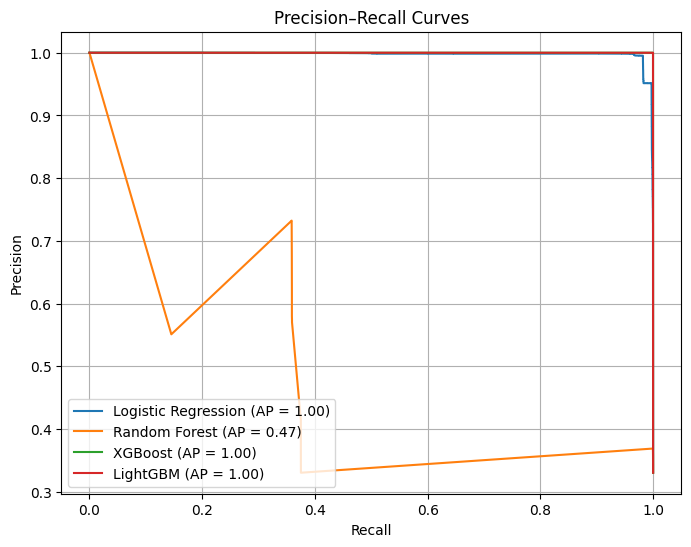

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Precision–Recall Curves
pr_results = {
    'Logistic Regression': (y_lr,    score_lr),
    'Random Forest':       (y_rf,    score_rf),
    'XGBoost':             (y_xgb,   score_xgb),
    'LightGBM':            (y_lgb,   score_lgb),
}

plt.figure(figsize=(8,6))
for name, (y_pred, y_score) in pr_results.items():
    precision, recall, _ = precision_recall_curve(y_test, y_score)
    ap = average_precision_score(y_test, y_score)
    plt.plot(recall, precision, label=f'{name} (AP = {ap:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curves')
plt.legend()
plt.grid(True)
plt.show()


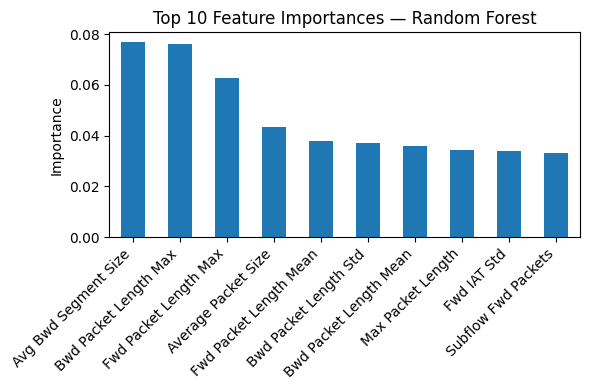

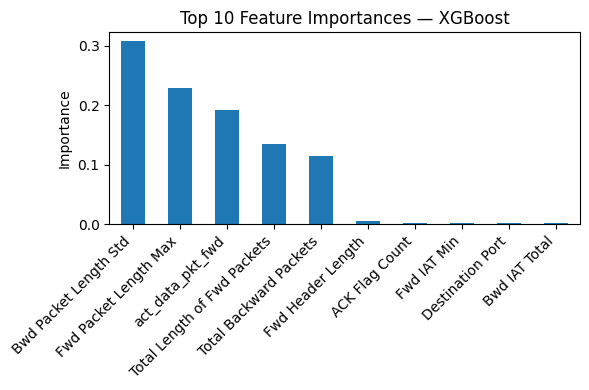

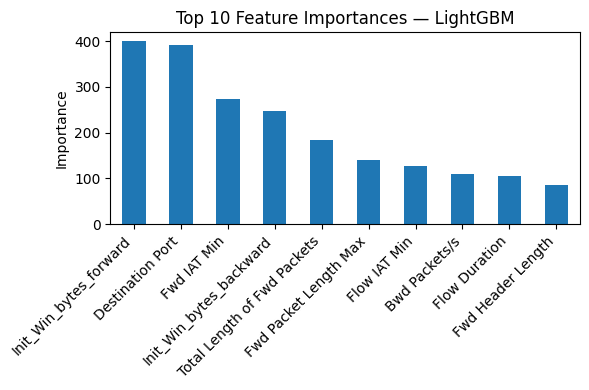

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract the top 10 features for each ensemble
fi = {
    'Random Forest':    best_rf.feature_importances_,
    'XGBoost':          xgbc.feature_importances_,
    'LightGBM':         lgbm.feature_importances_
}
feature_names = X.columns  # original feature names

for name, importances in fi.items():
    imp_df = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(10)
    plt.figure(figsize=(6,4))
    imp_df.plot.bar()
    plt.title(f'Top 10 Feature Importances — {name}')
    plt.ylabel('Importance')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


/usr/local/lib/python3.11/dist-packages/shap/explainers/_tree.py:544: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


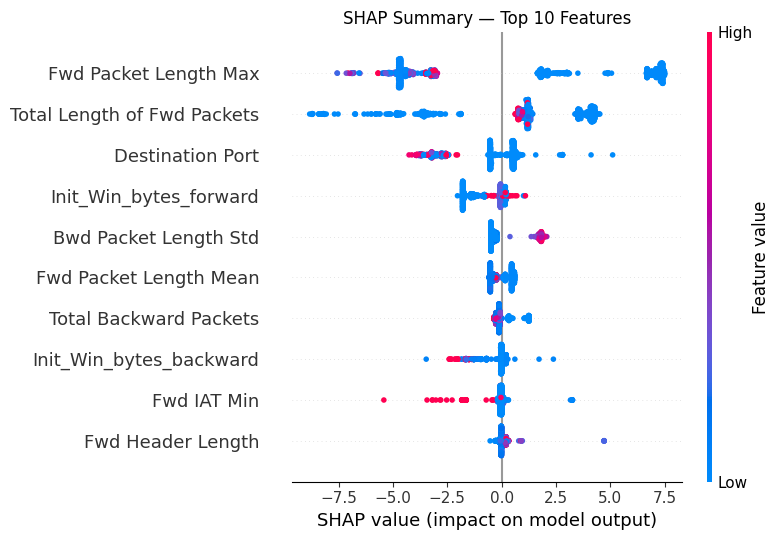

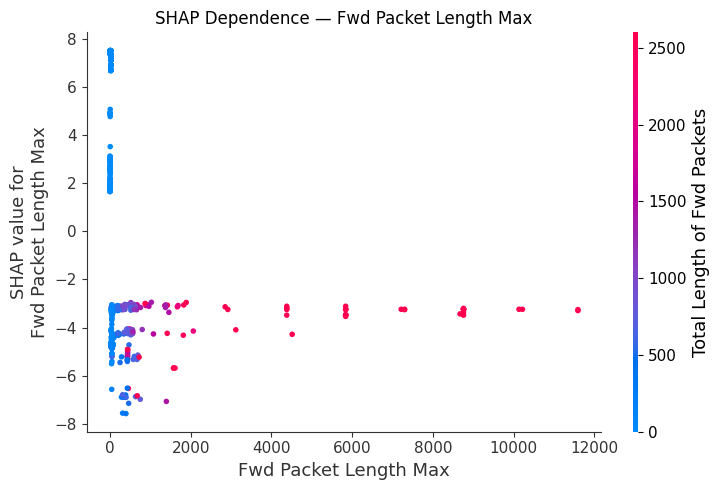

In [ ]:
import shap

# 1️ Create a SHAP TreeExplainer for LightGBM
explainer = shap.TreeExplainer(lgbm)
# Sample a subset to speed things up (e.g., first 1 000 test rows)
X_sample = X_test.iloc[:1000]
shap_values = explainer.shap_values(X_sample)

# 2️ SHAP Summary (Beeswarm) — Top 10 features
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=X.columns,
    max_display=10,
    show=False
)
plt.title("SHAP Summary — Top 10 Features")
plt.tight_layout()
plt.show()

# 3️ SHAP Dependence Plot — for the top feature
top_feat = X.columns[np.argsort(np.abs(shap_values).mean(0))[-1]]
shap.dependence_plot(
    top_feat,
    shap_values,
    X_sample,
    feature_names=X.columns,
    show=False
)
plt.title(f"SHAP Dependence — {top_feat}")
plt.tight_layout()
plt.show()
